### **Imports**

In [119]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.datasets import fetch_california_housing, load_breast_cancer
from sklearn.metrics import (r2_score, mean_squared_error, mean_absolute_error, accuracy_score, 
                            classification_report, confusion_matrix, precision_score, recall_score)
from sklearn.model_selection import train_test_split
from typing import Tuple

### **Load data**

#### California Housing (used in tasks 2-3)

In [120]:
# Load California Housing dataset
housing = fetch_california_housing()
df_housing = pd.DataFrame(data=housing.data, columns=housing.feature_names)
# Add target column (average house value)
df_housing["AvgHouseVal"] = housing.target

df_housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   AvgHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [121]:
df_housing.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,AvgHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


#### Breast Cancer (used in tasks 6-7)

In [122]:
breast_cancer = load_breast_cancer(as_frame=True)
df_cancer = pd.DataFrame(data=breast_cancer.data, columns=breast_cancer.feature_names)
df_cancer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [123]:
df_cancer.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### **Task 1**

#### Implementation of simple linear regression using Ordinary Least Squares

In [124]:
class SimpleLinearRegression:
    """
    A simple implementation of Ordinary Least Squares (OLS) linear regression
    for one independent variable (simple linear regression).

    Attributes
    ----------
    slope_ : float
        Estimated slope (coefficient) of the regression line.
    intercept_ : float
        Estimated intercept of the regression line.
    fitted : bool
        Indicates whether the model has been fitted.
    """

    def __init__(self) -> None:
        """Initialize the regression model with empty parameters."""
        self.slope_: float = 0.0
        self.intercept_: float = 0.0
        self.fitted: bool = False

    def fit(self, X: np.ndarray, y: np.ndarray) -> None:
        """
        Fit the linear regression model using the Ordinary Least Squares method.

        Parameters
        ----------
        X : np.ndarray
            1D array of independent variable values.
        y : np.ndarray
            1D array of dependent variable values.

        Raises
        ------
        ValueError
            If X and y have different lengths or are not 1D arrays.
        """
        # Ensure inputs are 1D arrays
        if X.ndim != 1 or y.ndim != 1:
            raise ValueError("X and y must be 1D arrays.")
        if X.shape[0] != y.shape[0]:
            raise ValueError("X and y must have the same length.")

        # Compute means
        x_mean: float = np.mean(X)
        y_mean: float = np.mean(y)

        # Compute slope (beta_1) and intercept (beta_0)
        numerator: float = np.sum((X - x_mean) * (y - y_mean))
        denominator: float = np.sum((X - x_mean) ** 2)

        self.slope_ = numerator / denominator
        self.intercept_ = y_mean - self.slope_ * x_mean
        self.fitted = True

    def predict(self, X: np.ndarray) -> np.ndarray:
        """
        Predict target values using the fitted regression model.

        Parameters
        ----------
        X : np.ndarray
            1D array of independent variable values.

        Returns
        -------
        np.ndarray
            Predicted values corresponding to X.

        Raises
        ------
        RuntimeError
            If the model has not been fitted yet.
        """
        if not self.fitted:
            raise RuntimeError("Model must be fitted before prediction.")

        return self.intercept_ + self.slope_ * X

    def coefficients(self) -> Tuple[float, float]:
        """
        Return the estimated regression coefficients.

        Returns
        -------
        Tuple[float, float]
            (intercept, slope)
        """
        return self.intercept_, self.slope_

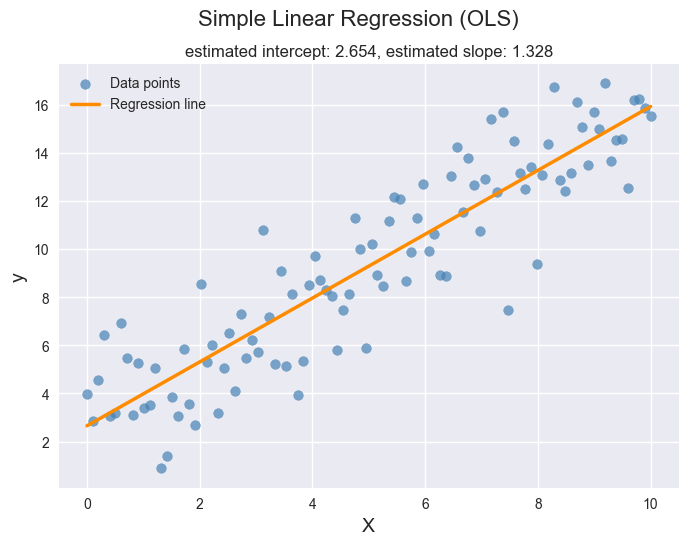

In [125]:
# Generate synthetic dataset
np.random.seed(42)
X_data = np.linspace(0, 10, 100)
true_slope = 1.3
true_intercept = 3
noise = np.random.normal(loc=0.0, scale=2.0, size=X_data.shape)
y_data = true_intercept + true_slope * X_data + noise

# Fit the model
model = SimpleLinearRegression()
model.fit(X_data, y_data)
y_pred = model.predict(X_data)

# Calculate coefficients
intercept, slope = model.coefficients()

# Plot the data and regression line
plt.style.use('seaborn-v0_8')
plt.scatter(X_data, y_data, color='steelblue', label='Data points', alpha=0.7)
plt.plot(X_data, y_pred, color='darkorange', linewidth=2.5, label='Regression line')
plt.suptitle('Simple Linear Regression (OLS)', fontsize=16)
plt.title(f"estimated intercept: {intercept:.3f}, estimated slope: {slope:.3f}")
plt.xlabel('X', fontsize=14)
plt.ylabel('y', fontsize=14)
plt.legend()

### **Task 2 and Task 3**

#### Linear regression using scikit-learn

In [126]:
# Generate synthetic dataset
np.random.seed(42)
X_data = np.linspace(0, 10, 100)
true_slope = 1.3
true_intercept = 3
noise = np.random.normal(loc=0.0, scale=2.0, size=X_data.shape)
y_data = true_intercept + true_slope * X_data + noise

In [127]:
# Fit scikit-learn LinearRegression
X_reshaped = X_data.reshape(-1, 1)
model_sklearn = LinearRegression()
model_sklearn.fit(X_reshaped, y_data)
y_pred_sklearn = model_sklearn.predict(X_reshaped)
intercept_sklearn = model_sklearn.intercept_
slope_sklearn = model_sklearn.coef_[0]

In [128]:
# Fit custom OLS
model_custom = SimpleLinearRegression()
model_custom.fit(X_data, y_data)
y_pred_custom = model_custom.predict(X_data)
intercept_custom, slope_custom = model_custom.coefficients()

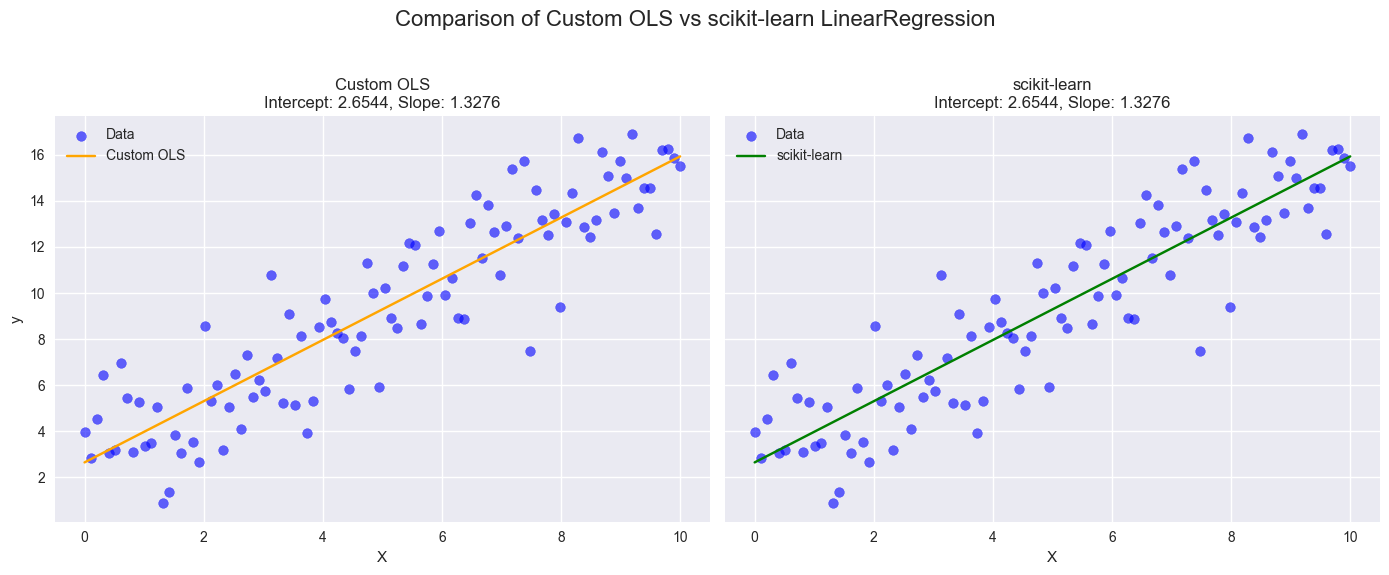

In [129]:
# Create side-by-side plots
plt.style.use('seaborn-v0_8')
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Custom OLS plot
axes[0].scatter(X_data, y_data, color='blue', alpha=0.6, label='Data')
axes[0].plot(X_data, y_pred_custom, color='orange', label='Custom OLS')
axes[0].set_title(f'Custom OLS\nIntercept: {intercept_custom:.4f}, Slope: {slope_custom:.4f}')
axes[0].set_xlabel('X')
axes[0].set_ylabel('y')
axes[0].legend()

# scikit-learn plot
axes[1].scatter(X_data, y_data, color='blue', alpha=0.6, label='Data')
axes[1].plot(X_data, y_pred_sklearn, color='green', label='scikit-learn')
axes[1].set_title(f'scikit-learn\nIntercept: {intercept_sklearn:.4f}, Slope: {slope_sklearn:.4f}')
axes[1].set_xlabel('X')
axes[1].legend()

# Suptitle
fig.suptitle('Comparison of Custom OLS vs scikit-learn LinearRegression', fontsize=16)
fig.tight_layout(rect=[0, 0.03, 1, 0.95])

#### Using a public dataset to build a multiple regression model

In [130]:
# Features and target
X = df_housing.drop(columns=["AvgHouseVal"]).values
y = df_housing["AvgHouseVal"].values

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [131]:
# Fit model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Coefficients and intercept
print("Intercept:", model.intercept_)
print("Coefficients:")
for feature, coef in zip(df_housing.columns[:-1], model.coef_):
    print(f"  {feature}: {coef:.4f}")

# Evaluation
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)


print(f"\nR² score: {r2:.3f}")
print(f"Mean Squared Error (MSE): {mse:.3f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.3f}")
print(f"Mean Absolute Error (MAE): {mae:.3f}")

Intercept: -37.02327770606397
Coefficients:
  MedInc: 0.4487
  HouseAge: 0.0097
  AveRooms: -0.1233
  AveBedrms: 0.7831
  Population: -0.0000
  AveOccup: -0.0035
  Latitude: -0.4198
  Longitude: -0.4337

R² score: 0.576
Mean Squared Error (MSE): 0.556
Root Mean Squared Error (RMSE): 0.746
Mean Absolute Error (MAE): 0.533


#### R² score (Coefficient of Determination) - Measures how much of the variance in the target variable is explained by the model. Values range from 0 to 1 (sometimes negative if the model is worse than a horizontal line).
#### MSE (Mean Squared Error) - The average of the squared differences between predicted and actual values.
#### RMSE (Root Mean Squared Error) - The square root of MSE, bringing the error back to the same units as the target variable.
#### MAE (Mean Absolute Error) - The average of the absolute differences between predicted and actual values. More robust to outliers than MSE/RMSE, but less sensitive to large deviations.

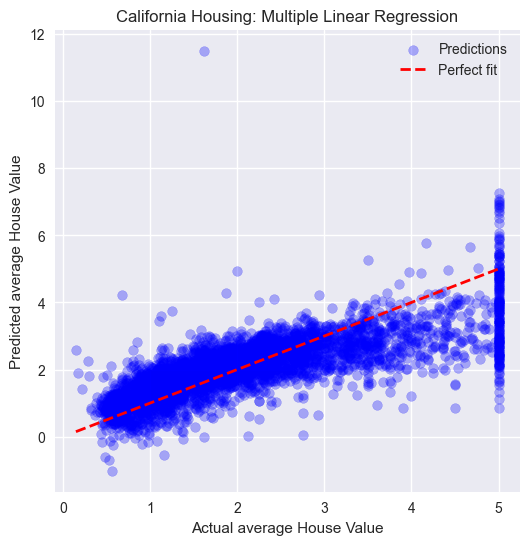

In [132]:
# Visualization
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color="blue", label="Predictions")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         "r--", lw=2, label="Perfect fit")
plt.xlabel("Actual average House Value")
plt.ylabel("Predicted average House Value")
plt.title("California Housing: Multiple Linear Regression")
plt.legend()
plt.show()

### **Task 4**

#### Regularization - Ridge and Lasso (prevent overfitting)

In [133]:
# Set random seed for reproducibility
np.random.seed(42)

# Generate synthetic data
X = np.linspace(0, 10, 100)
y_true = 1.5 * X + 2.0
noise = np.random.normal(0, 2, size=X.shape)
y = y_true + noise
X_reshaped = X.reshape(-1, 1)

In [134]:
# Fit models
models = {
    "LinearRegression": LinearRegression(),
    #In Ridge, you often need a larger α to see a noticeable effect, because the squared penalty grows more gradually.
    "Ridge": Ridge(alpha=1.0),
    # In Lasso, even a small α can strongly affect coefficients, sometimes zeroing them out
    "Lasso": Lasso(alpha=0.1)
}

fitted_lines = {}
intercepts = {}
slopes = {}

for name, model in models.items():
    model.fit(X_reshaped, y)
    y_pred = model.predict(X_reshaped)
    fitted_lines[name] = y_pred
    intercepts[name] = model.intercept_
    slopes[name] = model.coef_[0]

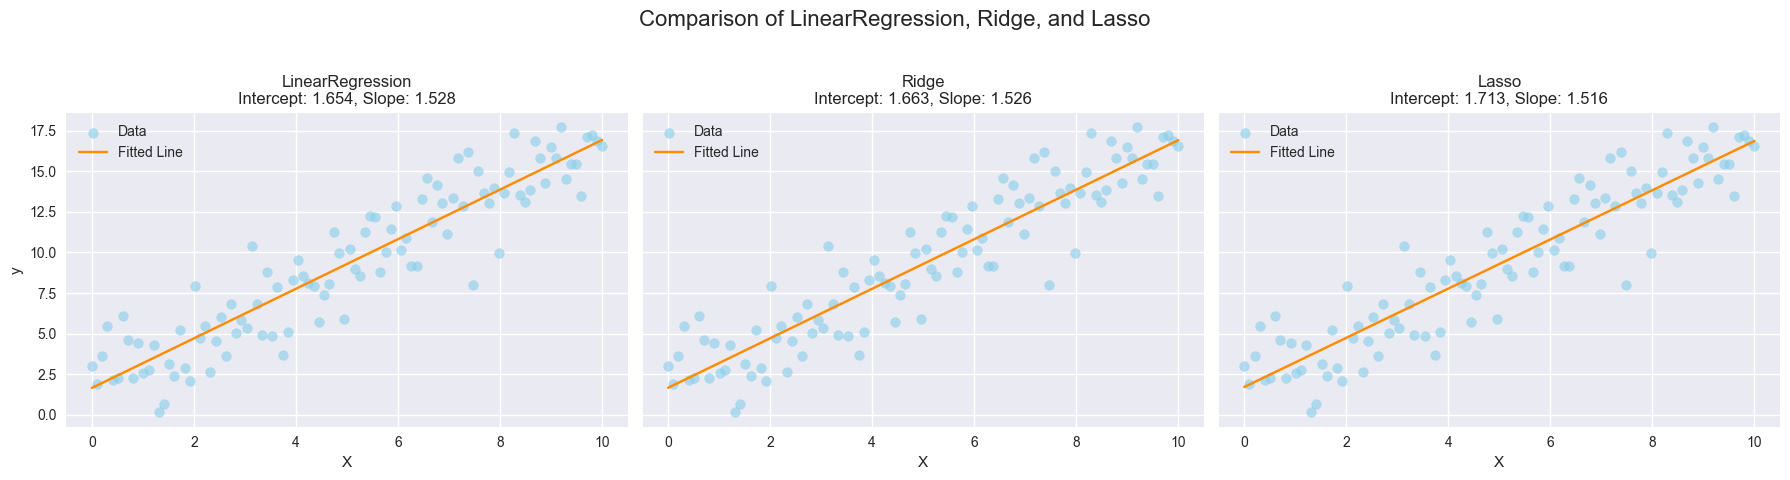

In [135]:
# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
model_names = list(models.keys())

for i, ax in enumerate(axes):
    name = model_names[i]
    ax.scatter(X, y, color='skyblue', label='Data', alpha=0.6)
    ax.plot(X, fitted_lines[name], color='darkorange', label='Fitted Line')
    ax.set_title(f"{name}\nIntercept: {intercepts[name]:.3f}, Slope: {slopes[name]:.3f}")
    ax.set_xlabel("X")
    if i == 0:
        ax.set_ylabel("y")
    ax.legend()

fig.suptitle("Comparison of LinearRegression, Ridge, and Lasso", fontsize=16)
fig.tight_layout(rect=[0, 0.03, 1, 0.95])

#### The coefficients are very close across all three models because we only have one feature.

#### Ridge adds a penalty depending on the square of the coefficients, which reduces their size but rarely sets them to zero, performing well with many features with small effects. Lasso adds a penalty depending on the absolute value of the coefficients, which can lead to some coefficients being set exactly to zero and thus performing feature selection.

#### Regularization stabilizes coefficients when noise is present.

### **Task 5**

In [136]:
def sigmoid(x: np.ndarray) -> np.ndarray:
    """
    Compute the sigmoid function for the input array.

    The sigmoid function is defined as:
        sigmoid(x) = 1 / (1 + exp(-x))

    Parameters
    ----------
    x : np.ndarray
        Input array of values.

    Returns
    -------
    np.ndarray
        Output array where the sigmoid function has been applied element-wise.
    """
    return 1 / (1 + np.exp(-x))

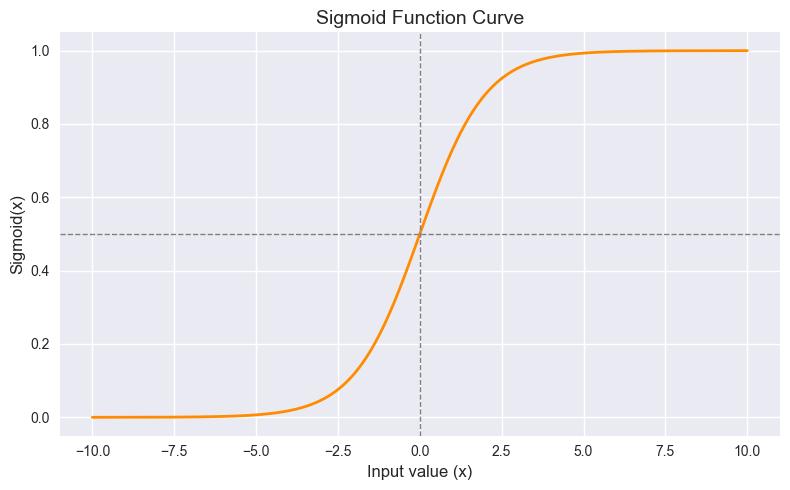

In [137]:
# Generate input values from -10 to 10
x_values = np.linspace(-10, 10, 400)
y_values = sigmoid(x_values)

# Plot the sigmoid curve
plt.style.use("seaborn-v0_8")
plt.figure(figsize=(8, 5))
plt.plot(x_values, y_values, color="darkorange", linewidth=2)
plt.title("Sigmoid Function Curve", fontsize=14)
plt.xlabel("Input value (x)", fontsize=12)
plt.ylabel("Sigmoid(x)", fontsize=12)
plt.grid(True)
plt.axhline(0.5, color="gray", linestyle="--", linewidth=1)
plt.axvline(0, color="gray", linestyle="--", linewidth=1)
plt.tight_layout()

#### Role in logistic regression: In linear regression, the result can take any value from −∞ to +∞. We use a sigmoid function to transform the result of a linear combination of features into a probability in the range [0,1].

#### Role in binary classification: Simple decision threshold - we usually assume that if σ(x) ≥ 0.5, we classify as class 1, otherwise as class 0. Monotonicity - larger input values always lead to higher probabilities, which is intuitive in classification.

### **Task 6**

#### Logistic regression model - breast cancer data

In [138]:
df_cancer['target'] = breast_cancer.target
# Split dataset into features and target
X = df_cancer.drop(columns='target')
y = df_cancer['target']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Initialize and fit logistic regression model
model = LogisticRegression(max_iter=10000, solver='liblinear')
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)

# Evaluate model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, output_dict=False)
conf_matrix = confusion_matrix(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print("\nClassification Report:\n", report)

Accuracy: 0.965
Precision: 0.972
Recall: 0.972

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.95      0.95        42
           1       0.97      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.96      0.96       114
weighted avg       0.96      0.96      0.96       114



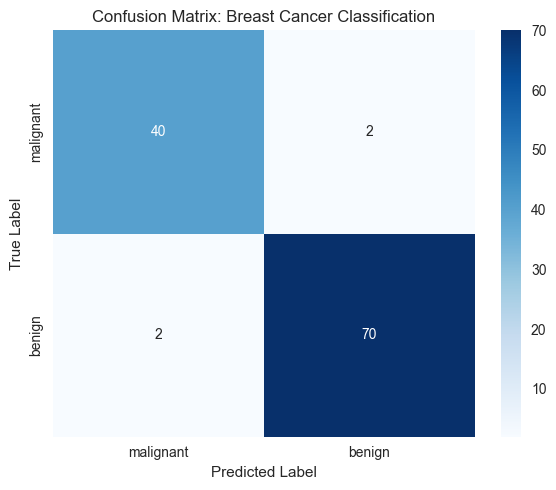

In [139]:
# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=breast_cancer.target_names,
            yticklabels=breast_cancer.target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix: Breast Cancer Classification")
plt.tight_layout()

#### High accuracy and very few misclassifications show that logistic regression is well‑suited for this dataset.